<a href="https://colab.research.google.com/github/maddi-venkata-teja/Algoverse-Chatbot/blob/main/algoverse_176.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week-1:Ground Truth Sets

Create Raw Dataset

In [ ]:
import pandas as pd
data = {
    "text": [
        "Amazing customer support",
        "Worst purchase ever",
        "Product is okay",
        "Very happy with the service",
        "Terrible delivery experience",
        "Highly recommended",
        "Average quality",
        "Excellent performance",
        "Poor packaging",
        "Not bad",
        "Loved it",
        "Horrible experience",
        "Fantastic quality",
        "Could be better",
        "Works perfectly"
    ],
    "label": [
        "Positive",
        "Negative",
        "Neutral",
        "Positive",
        "Negative",
        "Positive",
        "Neutral",
        "Positive",
        "Negative",
        "Neutral",
        "Positive",
        "Negative",
        "Positive",
        "Neutral",
        "Positive"
    ]
}

df = pd.DataFrame(data)

df.to_csv("raw_dataset.csv", index=False)

print(df.head())

                           text     label
0      Amazing customer support  Positive
1           Worst purchase ever  Negative
2               Product is okay   Neutral
3   Very happy with the service  Positive
4  Terrible delivery experience  Negative


Load Dataset

In [ ]:
df = pd.read_csv("raw_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (15, 2)


,text,label
0,Amazing customer support,Positive
1,Worst purchase ever,Negative
2,Product is okay,Neutral
3,Very happy with the service,Positive
4,Terrible delivery experience,Negative


Data Cleaning

In [ ]:
def clean_text(text):
    text = text.lower().strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df.to_csv("cleaned_dataset.csv", index=False)

df.head()

,text,label,clean_text
0,Amazing customer support,Positive,amazing customer support
1,Worst purchase ever,Negative,worst purchase ever
2,Product is okay,Neutral,product is okay
3,Very happy with the service,Positive,very happy with the service
4,Terrible delivery experience,Negative,terrible delivery experience


Simulate Human Annotation

In [ ]:
import random
labels = ["Positive", "Negative", "Neutral"]

def annotator(true_label, agreement=0.85):
    if random.random() < agreement:
        return true_label
    remaining = [label for label in labels if label != true_label]
    return random.choice(remaining)

df["Annotator_1"] = df["label"].apply(lambda x: annotator(x))
df["Annotator_2"] = df["label"].apply(lambda x: annotator(x))
df["Annotator_3"] = df["label"].apply(lambda x: annotator(x))

df.head()

,text,label,clean_text,Annotator_1,Annotator_2,Annotator_3
0,Amazing customer support,Positive,amazing customer support,Positive,Neutral,Positive
1,Worst purchase ever,Negative,worst purchase ever,Negative,Negative,Positive
2,Product is okay,Neutral,product is okay,Positive,Positive,Neutral
3,Very happy with the service,Positive,very happy with the service,Positive,Positive,Positive
4,Terrible delivery experience,Negative,terrible delivery experience,Negative,Negative,Negative


Build Ground Truth

In [ ]:
def majority_vote(row):
    votes = [
        row["Annotator_1"],
        row["Annotator_2"],
        row["Annotator_3"]
    ]
    return max(set(votes), key=votes.count)

df["GroundTruth"] = df.apply(majority_vote, axis=1)

df.head()

,text,label,clean_text,Annotator_1,Annotator_2,Annotator_3,GroundTruth
0,Amazing customer support,Positive,amazing customer support,Positive,Neutral,Positive,Positive
1,Worst purchase ever,Negative,worst purchase ever,Negative,Negative,Positive,Negative
2,Product is okay,Neutral,product is okay,Positive,Positive,Neutral,Positive
3,Very happy with the service,Positive,very happy with the service,Positive,Positive,Positive,Positive
4,Terrible delivery experience,Negative,terrible delivery experience,Negative,Negative,Negative,Negative


Annotation Agreement

In [ ]:
from sklearn.metrics import cohen_kappa_score
kappa12 = cohen_kappa_score(df["Annotator_1"], df["Annotator_2"])
kappa13 = cohen_kappa_score(df["Annotator_1"], df["Annotator_3"])
kappa23 = cohen_kappa_score(df["Annotator_2"], df["Annotator_3"])

agreement = pd.DataFrame(
    {
        "Annotator Pair": [
            "A1 vs A2",
            "A1 vs A3",
            "A2 vs A3"
        ],
        "Cohen Kappa": [
            kappa12,
            kappa13,
            kappa23
        ]
    }
)

agreement

,Annotator Pair,Cohen Kappa
0,A1 vs A2,0.468085
1,A1 vs A3,0.482759
2,A2 vs A3,0.285714


Visualize Label Distribution

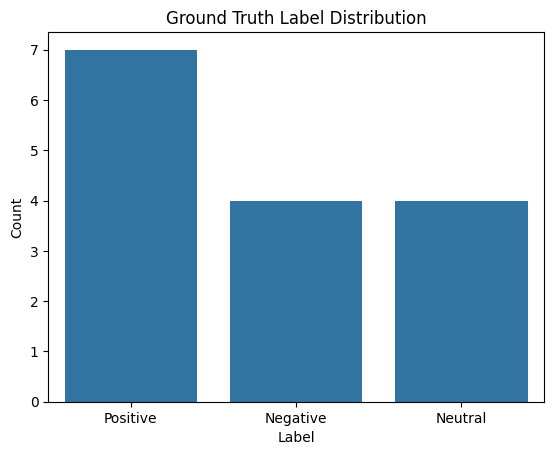

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    data=df,
    x="GroundTruth",
    order=df["GroundTruth"].value_counts().index
)

plt.title("Ground Truth Label Distribution")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

Visualize Annotation Agreement

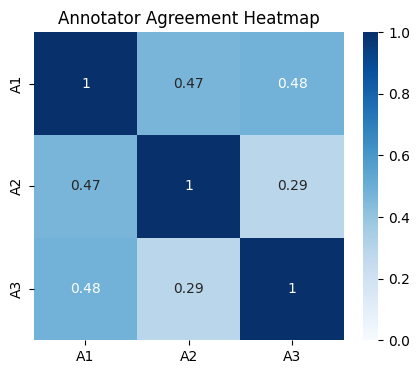

In [ ]:
heatmap_data = pd.DataFrame(
    [
        [1, kappa12, kappa13],
        [kappa12, 1, kappa23],
        [kappa13, kappa23, 1]
    ],
    columns=["A1", "A2", "A3"],
    index=["A1", "A2", "A3"]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title("Annotator Agreement Heatmap")

plt.show()

Export Ground Truth Datase

In [ ]:
df.to_csv("ground_truth_dataset.csv", index=False)

print("Ground Truth Dataset Exported Successfully!")
print(df.head())

Ground Truth Dataset Exported Successfully!
                           text     label                    clean_text  \
0      Amazing customer support  Positive      amazing customer support   
1           Worst purchase ever  Negative           worst purchase ever   
2               Product is okay   Neutral               product is okay   
3   Very happy with the service  Positive   very happy with the service   
4  Terrible delivery experience  Negative  terrible delivery experience   

  Annotator_1 Annotator_2 Annotator_3 GroundTruth  
0    Positive     Neutral    Positive    Positive  
1    Negative    Negative    Positive    Negative  
2    Positive    Positive     Neutral    Positive  
3    Positive    Positive    Positive    Positive  
4    Negative    Negative    Negative    Negative  


Week-2:Difficulty Scaling

In [ ]:
!pip install pandas numpy matplotlib seaborn textstat -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.4 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import textstat

plt.style.use("ggplot")

Create Dataset

In [ ]:
questions = {
    "question": [
        "What is AI?",
        "Define Machine Learning.",
        "Explain supervised learning with examples.",
        "Compare CNN and RNN architectures.",
        "Explain the Transformer architecture.",
        "What is overfitting?",
        "Describe gradient descent optimization.",
        "Explain reinforcement learning in detail.",
        "Differentiate precision and recall.",
        "Discuss the ethical challenges of Generative AI."
    ]
}

df = pd.DataFrame(questions)

df.to_csv("raw_questions.csv", index=False)

df.head()

,question
0,What is AI?
1,Define Machine Learning.
2,Explain supervised learning with examples.
3,Compare CNN and RNN architectures.
4,Explain the Transformer architecture.


Load Dataset

In [ ]:
df = pd.read_csv("raw_questions.csv")

print(df.shape)

df.head()

(10, 1)


,question
0,What is AI?
1,Define Machine Learning.
2,Explain supervised learning with examples.
3,Compare CNN and RNN architectures.
4,Explain the Transformer architecture.


Text Cleaning

In [ ]:
df["clean_question"] = (
    df["question"]
      .str.lower()
      .str.strip()
)

Feature Engineering

In [ ]:
df["Word_Count"] = df["clean_question"].apply(
    lambda x: len(x.split())
)

df["Character_Count"] = df["clean_question"].apply(len)

df["Average_Word_Length"] = (
    df["Character_Count"] /
    df["Word_Count"]
)

df["Readability"] = df["clean_question"].apply(
    textstat.flesch_reading_ease
)

df.head()

,question,clean_question,Word_Count,Character_Count,Average_Word_Length,Readability
0,What is AI?,what is ai?,3,11,3.666667,119.190
1,Define Machine Learning.,define machine learning.,3,24,8.000000,34.590
2,Explain supervised learning with examples.,explain supervised learning with examples.,5,42,8.400000,15.640
3,Compare CNN and RNN architectures.,compare cnn and rnn architectures.,5,34,6.800000,15.640
4,Explain the Transformer architecture.,explain the transformer architecture.,4,37,9.250000,-8.725


Difficulty Score

In [ ]:
df["Difficulty_Score"] = (
    0.4 * df["Word_Count"] +
    0.3 * df["Average_Word_Length"] +
    0.3 * (100 - df["Readability"])
)

Difficulty Categories

In [ ]:
def difficulty(score):

    if score < 20:
        return "Easy"

    elif score < 40:
        return "Medium"

    else:
        return "Hard"

df["Difficulty_Level"] = df["Difficulty_Score"].apply(
    difficulty
)

df.head()

,question,clean_question,Word_Count,Character_Count,Average_Word_Length,Readability,Difficulty_Score,Difficulty_Level
0,What is AI?,what is ai?,3,11,3.666667,119.190,-3.4570,Easy
1,Define Machine Learning.,define machine learning.,3,24,8.000000,34.590,23.2230,Medium
2,Explain supervised learning with examples.,explain supervised learning with examples.,5,42,8.400000,15.640,29.8280,Medium
3,Compare CNN and RNN architectures.,compare cnn and rnn architectures.,5,34,6.800000,15.640,29.3480,Medium
4,Explain the Transformer architecture.,explain the transformer architecture.,4,37,9.250000,-8.725,36.9925,Medium


Visualize Difficulty Distribution

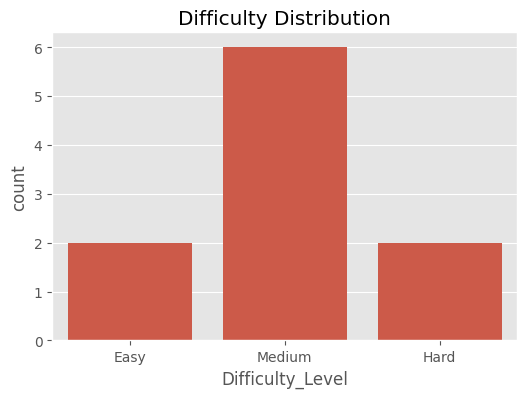

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Difficulty_Level",
    order=["Easy","Medium","Hard"]
)

plt.title("Difficulty Distribution")

plt.show()

Histogram

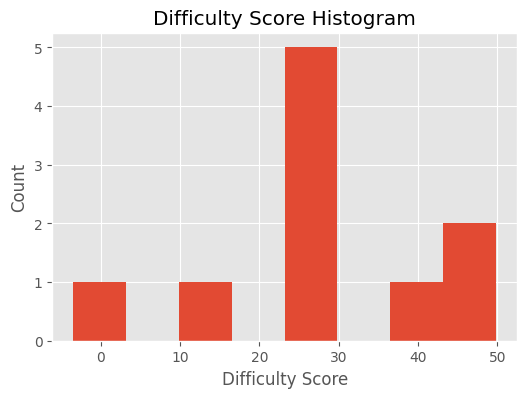

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df["Difficulty_Score"], bins=8)

plt.xlabel("Difficulty Score")

plt.ylabel("Count")

plt.title("Difficulty Score Histogram")

plt.show()

Export Dataset

In [ ]:
df.to_csv(
    "processed_questions.csv",
    index=False
)

print("Dataset exported successfully!")

df.head()

Dataset exported successfully!


,question,clean_question,Word_Count,Character_Count,Average_Word_Length,Readability,Difficulty_Score,Difficulty_Level
0,What is AI?,what is ai?,3,11,3.666667,119.190,-3.4570,Easy
1,Define Machine Learning.,define machine learning.,3,24,8.000000,34.590,23.2230,Medium
2,Explain supervised learning with examples.,explain supervised learning with examples.,5,42,8.400000,15.640,29.8280,Medium
3,Compare CNN and RNN architectures.,compare cnn and rnn architectures.,5,34,6.800000,15.640,29.3480,Medium
4,Explain the Transformer architecture.,explain the transformer architecture.,4,37,9.250000,-8.725,36.9925,Medium


Week-3:Bias Detection

In [ ]:
!pip install pandas numpy matplotlib seaborn -q

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Create Dataset

In [ ]:
texts = {
    "text": [
        "Women are better teachers.",
        "Men are stronger than women.",
        "Everyone deserves equal opportunities.",
        "Older employees are less productive.",
        "Young professionals adapt quickly.",
        "All cultures should be respected.",
        "People from rural areas are uneducated.",
        "Experience matters more than age.",
        "Engineers solve difficult problems.",
        "Leadership depends on skills, not gender."
    ]
}

df = pd.DataFrame(texts)

df.to_csv("raw_text.csv", index=False)

df.head()

,text
0,Women are better teachers.
1,Men are stronger than women.
2,Everyone deserves equal opportunities.
3,Older employees are less productive.
4,Young professionals adapt quickly.


Load Dataset

In [ ]:
df = pd.read_csv("raw_text.csv")

print(df.shape)

df.head()

(10, 1)


,text
0,Women are better teachers.
1,Men are stronger than women.
2,Everyone deserves equal opportunities.
3,Older employees are less productive.
4,Young professionals adapt quickly.


Text Cleaning

In [ ]:
df["clean_text"] = (
    df["text"]
      .str.lower()
      .str.strip()
)

Define Bias Keywords

In [ ]:
bias_keywords = {
    "Gender": [
        "men",
        "women",
        "gender"
    ],
    "Age": [
        "young",
        "older",
        "age"
    ],
    "Culture": [
        "culture",
        "cultures",
        "rural"
    ]
}

Detect Bias

In [ ]:
def detect_bias(text):

    detected = []

    for category, words in bias_keywords.items():

        for word in words:

            if word in text:
                detected.append(category)
                break

    if len(detected) == 0:
        return "None"

    return ", ".join(detected)

df["Bias_Category"] = df["clean_text"].apply(detect_bias)

df.head()

,text,clean_text,Bias_Category
0,Women are better teachers.,women are better teachers.,Gender
1,Men are stronger than women.,men are stronger than women.,Gender
2,Everyone deserves equal opportunities.,everyone deserves equal opportunities.,None
3,Older employees are less productive.,older employees are less productive.,Age
4,Young professionals adapt quickly.,young professionals adapt quickly.,Age


Bias Flag

In [ ]:
df["Bias_Flag"] = df["Bias_Category"].apply(
    lambda x: "Yes" if x != "None" else "No"
)

df.head()

,text,clean_text,Bias_Category,Bias_Flag
0,Women are better teachers.,women are better teachers.,Gender,Yes
1,Men are stronger than women.,men are stronger than women.,Gender,Yes
2,Everyone deserves equal opportunities.,everyone deserves equal opportunities.,None,No
3,Older employees are less productive.,older employees are less productive.,Age,Yes
4,Young professionals adapt quickly.,young professionals adapt quickly.,Age,Yes


Bias Statistics

In [ ]:
bias_summary = (
    df["Bias_Category"]
      .value_counts()
      .reset_index()
)

bias_summary.columns = [
    "Bias_Category",
    "Count"
]

bias_summary

,Bias_Category,Count
0,Gender,3
1,Age,3
2,None,2
3,Culture,2


Bar Chart

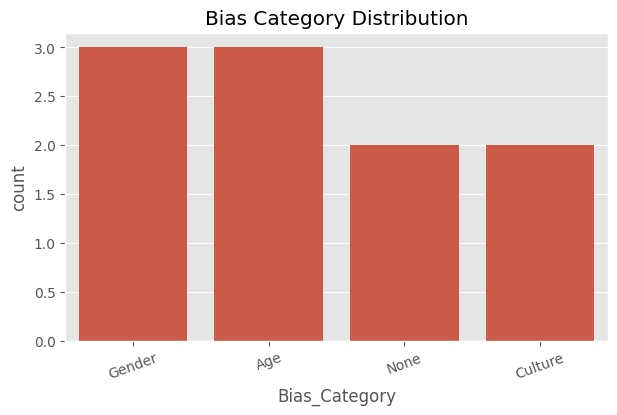

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Bias_Category",
    order=df["Bias_Category"].value_counts().index
)

plt.xticks(rotation=20)

plt.title("Bias Category Distribution")

plt.show()

Pie Chart

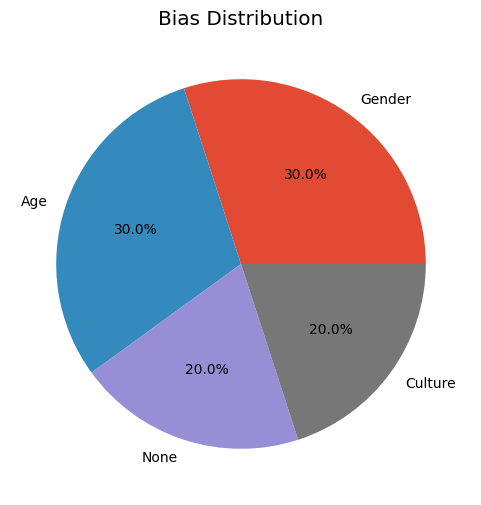

In [ ]:
plt.figure(figsize=(6,6))

df["Bias_Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Bias Distribution")

plt.show()

Export Report

In [ ]:
df.to_csv(
    "bias_report.csv",
    index=False
)

print("Bias report exported successfully!")

df.head()

Bias report exported successfully!


,text,clean_text,Bias_Category,Bias_Flag
0,Women are better teachers.,women are better teachers.,Gender,Yes
1,Men are stronger than women.,men are stronger than women.,Gender,Yes
2,Everyone deserves equal opportunities.,everyone deserves equal opportunities.,None,No
3,Older employees are less productive.,older employees are less productive.,Age,Yes
4,Young professionals adapt quickly.,young professionals adapt quickly.,Age,Yes


Week-4:Model Card Creation

In [ ]:
!pip install pandas matplotlib seaborn -q

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Create Sample Metadata

In [ ]:
metadata = {
    "Model_Name": ["SentimentClassifier"],
    "Version": ["1.0"],
    "Accuracy": [0.92],
    "Precision": [0.91],
    "Recall": [0.90],
    "F1_Score": [0.905],
    "Training_Data": ["Movie Reviews Dataset"],
    "Intended_Use": ["Sentiment Analysis"],
    "Limitations": ["Not suitable for multilingual text"]
}

df = pd.DataFrame(metadata)

df.to_csv("model_metadata.csv", index=False)

df

,Model_Name,Version,Accuracy,Precision,Recall,F1_Score,Training_Data,Intended_Use,Limitations
0,SentimentClassifier,1.0,0.92,0.91,0.9,0.905,Movie Reviews Dataset,Sentiment Analysis,Not suitable for multilingual text


Load Dataset

In [ ]:
df = pd.read_csv("model_metadata.csv")

df.head()

,Model_Name,Version,Accuracy,Precision,Recall,F1_Score,Training_Data,Intended_Use,Limitations
0,SentimentClassifier,1.0,0.92,0.91,0.9,0.905,Movie Reviews Dataset,Sentiment Analysis,Not suitable for multilingual text


Performance Visualization

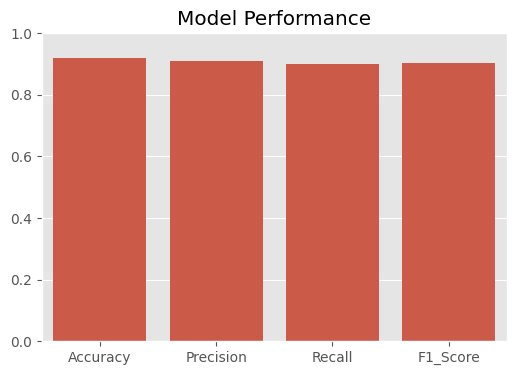

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1_Score"]
scores = df.loc[0, metrics]

plt.figure(figsize=(6,4))

sns.barplot(x=metrics, y=scores.values)

plt.ylim(0,1)

plt.title("Model Performance")

plt.show()

Generate Model Card

In [ ]:
model_card = f"""
# Model Card

## Model Name
{df.loc[0,'Model_Name']}

## Version
{df.loc[0,'Version']}

## Intended Use
{df.loc[0,'Intended_Use']}

## Training Data
{df.loc[0,'Training_Data']}

## Performance

Accuracy : {df.loc[0,'Accuracy']}
Precision: {df.loc[0,'Precision']}
Recall   : {df.loc[0,'Recall']}
F1 Score : {df.loc[0,'F1_Score']}

## Limitations

{df.loc[0,'Limitations']}
"""

with open("model_card.md", "w") as f:
    f.write(model_card)

print(model_card)


# Model Card

## Model Name
SentimentClassifier

## Version
1.0

## Intended Use
Sentiment Analysis

## Training Data
Movie Reviews Dataset

## Performance

Accuracy : 0.92
Precision: 0.91
Recall   : 0.9
F1 Score : 0.905

## Limitations

Not suitable for multilingual text



Export Files

In [ ]:
df.to_csv("processed_metadata.csv", index=False)

print("Model Card Generated Successfully!")

Model Card Generated Successfully!
